# Correlation between MACE-predicted and DFT-relaxed energies

This notebook evaluates the correlations of relative MACE single-point energies ($\Delta E_{\mathrm{MACE-SP}}$) and relative MACE-relaxed enegies ($\Delta E_{\mathrm{MACE-relaxed}}$) with DFT-relaxed energies ($\Delta E_{\mathrm{relaxed}}$) for:

- KI/NaCl
- GaP/GaAs
- GaN/$\mathrm{Al_{2}O_{3}}$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress, t
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = ["KI/NaCl", "GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
dft_paths = [f"dft_results/{system}.csv" for system in systems]
# Column names
mace_sp_col = "mace_single_point_energy"
mace_relaxed_col = "mace_relaxed_energy"
dft_relaxed_col = "dft_relaxed_energy"
# Figure layout 
fig_width = 7.2
fig_height = 4.5
fig_layout = dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.4,
    hspace=0.4,
)
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
panel_label_size = 14
# Scatter and fitting style
point_color = "#3F6C88"
point_size = 18
ci_color = "#D3D3D3"
fit_color = "#000000"


## Linear regression with confidence intervals


In [2]:
def fit_linear_with_ci(xi, yi, confidence=0.95, n_grid=200):
    xi = np.asarray(xi, dtype=float)
    yi = np.asarray(yi, dtype=float)
    fit = linregress(xi, yi)
    x_fit = np.linspace(xi.min(), xi.max(), n_grid)
    y_fit = fit.slope * x_fit + fit.intercept
    n = len(xi)
    x_mean = np.mean(xi)
    sxx = np.sum((xi-x_mean) ** 2)
    y_pred = fit.intercept + fit.slope * xi
    resids = yi - y_pred
    s_err = np.sqrt(np.sum(resids**2) / (n-2))
    t_crit = t.ppf((1.0+confidence)/2.0, df=n-2)
    se_mean = s_err * np.sqrt(1.0/n+(x_fit-x_mean)**2/sxx)
    ci = t_crit * se_mean
    y_lower = y_fit - ci
    y_upper = y_fit + ci
    return x_fit, y_fit, y_lower, y_upper


## Data processing and correlation analysis


In [3]:
sp_data = []
relaxed_data = []

for title, dft_path in zip(titles, dft_paths):
    df = pd.read_csv(dft_path).copy()
    # Convert absolute values to relative values for better visualization.
    mace_sp = (df[mace_sp_col]-df[mace_sp_col].min()).to_numpy(dtype=float)
    mace_relaxed = (df[mace_relaxed_col]-df[mace_relaxed_col].min()).to_numpy(dtype=float)
    dft_relaxed = (df[dft_relaxed_col]-df[dft_relaxed_col].min()).to_numpy(dtype=float)
    mace_sp_r = float(pearsonr(mace_sp, dft_relaxed).statistic)
    mace_sp_rho = float(spearmanr(mace_sp, dft_relaxed).statistic)
    mace_relaxed_r = float(pearsonr(mace_relaxed, dft_relaxed).statistic)
    mace_relaxed_rho = float(spearmanr(mace_relaxed, dft_relaxed).statistic)
    sp_data.append((title, mace_sp, dft_relaxed, mace_sp_r, mace_sp_rho))
    relaxed_data.append((title, mace_relaxed, dft_relaxed, mace_relaxed_r, mace_relaxed_rho))


## Plot correlations

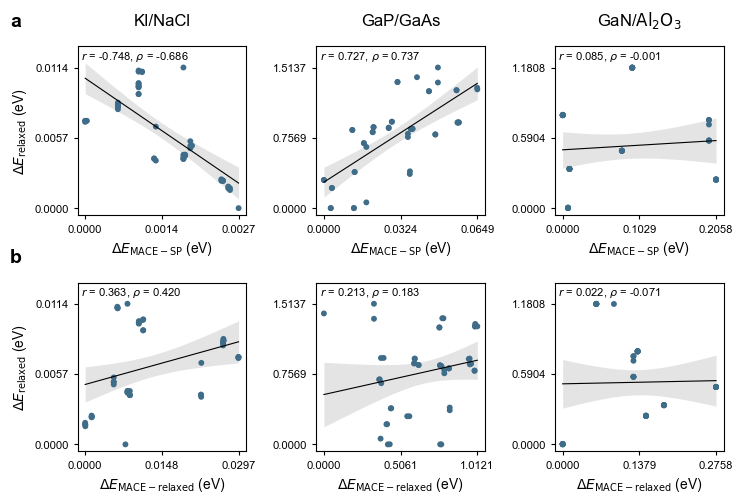

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))
plt.subplots_adjust(**fig_layout)

data_store = [sp_data, relaxed_data]
x_labels = [
    r"$\Delta E_{\mathrm{MACE-SP}}$ (eV)",
    r"$\Delta E_{\mathrm{MACE-relaxed}}$ (eV)",
]

for row_index, data in enumerate(data_store):
    for col_index, (title, x, y, r, rho) in enumerate(data):
        ax = axes[row_index, col_index]
        ax.set_box_aspect(1)
        ax.scatter(x, y, s=point_size, color=point_color, edgecolors="none", zorder=2)
        x_fit, y_fit, y_lower, y_upper = fit_linear_with_ci(x, y)
        ax.fill_between(x_fit, y_lower, y_upper, color=ci_color, alpha=0.6, linewidth=0, zorder=1)
        ax.plot(x_fit, y_fit, color=fit_color, linewidth=0.8, zorder=3)
        corr_label = rf"$r$ = {r:.3f}, $\rho$ = {rho:.3f}"
        ax.text(0.02, 0.98, corr_label, transform=ax.transAxes, ha="left", va="top")
        ax.tick_params(direction="out", length=3, width=0.8, top=False, right=False)
        ax.set_ylim(y.min()-0.05*(y.max()-y.min()), y.max()+0.15*(y.max()-y.min()))
        ax.set_xlim(x.min()-0.05*(x.max()-x.min()), x.max()+0.05*(x.max()-x.min()))
        ax.set_xticks(np.linspace(x.min(), x.max(), 3))
        ax.set_yticks(np.linspace(y.min(), y.max(), 3))
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
        if row_index == 0:
            ax.set_title(title, pad=15)
        if col_index == 0:
            ax.set_ylabel(r"$\Delta E_{\mathrm{relaxed}}$ (eV)")
        ax.set_xlabel(x_labels[row_index])

# Add row labels
axes[0, 0].text(
    -0.4, 1.12,
    "a",
    transform=axes[0, 0].transAxes,
    fontsize=panel_label_size,
    fontweight="bold",
)
axes[1, 0].text(
    -0.4, 1.12,
    "b",
    transform=axes[1, 0].transAxes,
    fontsize=panel_label_size,
    fontweight="bold",
)
# Output files
plt.savefig("mace_dft_relaxed_correlation.pdf", dpi=300, bbox_inches="tight")
plt.show()
